# Task 4 — Library-prep disentanglement

**Question:** Can library-associated variation be separated from biological variation in frozen BridgeRNA representations?

This is a standalone benchmark motivated by Task 3. BridgeRNA is frozen, and NASA/OSDR data are never used for training, model selection, or hyperparameter tuning. Computation lives in `pipeline/`; this notebook reads saved outputs. We use *library-associated* unless controlled evidence supports a causal claim.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
HERE = Path.cwd()
if HERE.name != 'library_prep_disentanglement':
    candidate = HERE / 'benchmarks/library_prep_disentanglement'
    if candidate.exists(): HERE = candidate
RESULTS = HERE / 'results'
def read_csv(path): return pd.read_csv(path) if path.exists() else pd.DataFrame()
def read_json(path): return json.loads(path.read_text()) if path.exists() else {}
print('Benchmark:', HERE.resolve())

Benchmark: /home/walt/bridge-rna/benchmarks/library_prep_disentanglement


## 1. Data discovery and provenance

ARCHS4 labels are audited conservatively: `total RNA` alone is not treated as proof of rRNA depletion. True same-RNA pairs require authoritative deposited metadata.

In [2]:
audit = read_json(RESULTS/'task4a_data_audit/archs4_audit_summary.json')
display(pd.DataFrame([audit]).T.rename(columns={0:'value'}))
display(read_csv(RESULTS/'task4a_data_audit/archs4_explicit_label_summary.csv'))
display(read_csv(RESULTS/'task4a_data_audit/controlled_dataset_audit.csv'))

,value
metadata_rows,940455
explicitly_labeled_samples,180015
explicit_polya_samples,178770
explicit_ribo_samples,1201
conflicting_samples,44
studies_with_both_labels,31
verified_same_rna_pairs,0
classification,OBSERVATIONAL
reason,"Explicit labels exist, but ARCHS4 metadata do ..."


,library_label,species,samples,studies
0,conflict,human,28,2
1,conflict,mouse,16,2
2,polyA,human,91554,4018
3,polyA,mouse,87216,4150
4,ribo,human,768,76
5,ribo,mouse,433,45


,dataset,accession,species,tissue,n_pairs,same_rna,polyA_protocol,ribo_protocol,platform,role
0,Chen 2020 T cells,doi:10.1038/s41597-020-00719-4; syn22250947; f...,human,naive CD4+ T cells,40,yes,TruSeq RNA Library Prep v2,TruSeq Stranded Total RNA + Ribo-Zero Gold,Illumina paired-end,TRAIN
1,GSE150097 freeze-thaw,GSE150097 / SRP257988,human,blood leukocytes,pending authoritative pair map,candidate; verify pair IDs,TruSeq Stranded mRNA,TruSeq Stranded Total RNA + Ribo-Zero Gold,HiSeq 4000 (SE50 vs PE100 confounded),VALIDATION candidate
2,Zhao 2018 blood/colon,SRP127360,human,pooled blood; colon,2,yes; four technical libraries/arm,TruSeq Stranded mRNA,Globin-Zero blood; Ribo-Zero Gold colon,NextSeq 500 PE,TEST


The controlled 40-donor T-cell study is used for training. SRP127360 is completely held out, but contains only two biological source RNAs (pooled blood and colon), with four technical libraries per protocol. GSE150097 is retained as a candidate because its public records do not establish every cross-protocol pair. This exploratory run therefore uses fixed epochs without validation-driven selection.

## 2. Original frozen BridgeRNA baseline

,samples,datasets,verified_pairs,median_pair_cosine,mean_pair_cosine,pair_recall_at_1,pair_recall_at_5,pair_recall_at_10,pair_mrr,median_pair_rank,difference_pc1_variance,interpretation
0,96,2,42,0.9976,0.9920,0.1071,0.2976,0.5119,0.2228,9.5000,0.9631,"A dominant direction is descriptive, not evidence of a universal causal library effect."


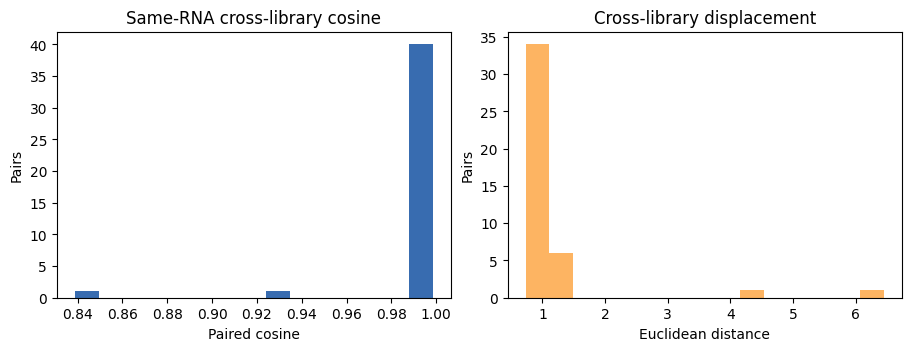

In [3]:
baseline = read_json(RESULTS/'task4c_bridge_baseline/summary.json')
display(pd.DataFrame([baseline]).style.format(precision=4))
pairs = read_csv(RESULTS/'task4c_bridge_baseline/bridge_pair_metrics.csv')
if len(pairs):
    fig, ax = plt.subplots(1, 2, figsize=(9, 3.4), layout='constrained')
    ax[0].hist(pairs.paired_cosine, bins=15, color='#386cb0')
    ax[0].set(xlabel='Paired cosine', ylabel='Pairs', title='Same-RNA cross-library cosine')
    ax[1].hist(pairs.euclidean_distance, bins=15, color='#fdb462')
    ax[1].set(xlabel='Euclidean distance', ylabel='Pairs', title='Cross-library displacement')
    plt.show()

High pair cosine does not guarantee donor retrieval. A dominant PolyA→Ribo difference component is evidence of reproducible displacement within a study, not proof of a universal causal library effect.

## 3. FE/RE decomposition and controls

,representation,auroc,balanced_accuracy,macro_f1,pairs,pair_cosine,pair_r1,pair_r5,pair_r10,pair_mrr,median_rank,biology_metric,biology_metric_value
0,Bridge,0.000,0.250,0.200,2,0.882,0.750,1.000,1.000,0.875,1.000,cross_library_source_identity_mrr,0.875
1,Linear baseline,0.500,0.500,0.333,2,0.883,0.750,1.000,1.000,0.875,1.000,cross_library_source_identity_mrr,0.875
2,FE,0.000,0.500,0.333,2,0.786,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
3,RE,0.000,0.250,0.200,2,0.165,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
4,FE without_pair,0.000,0.500,0.333,2,0.838,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
5,FE without_adversarial,0.078,0.250,0.200,2,0.996,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
6,FE shuffled_labels,0.000,0.000,0.000,2,1.000,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
7,FE shuffled_pairs,0.000,0.500,0.333,2,0.986,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750


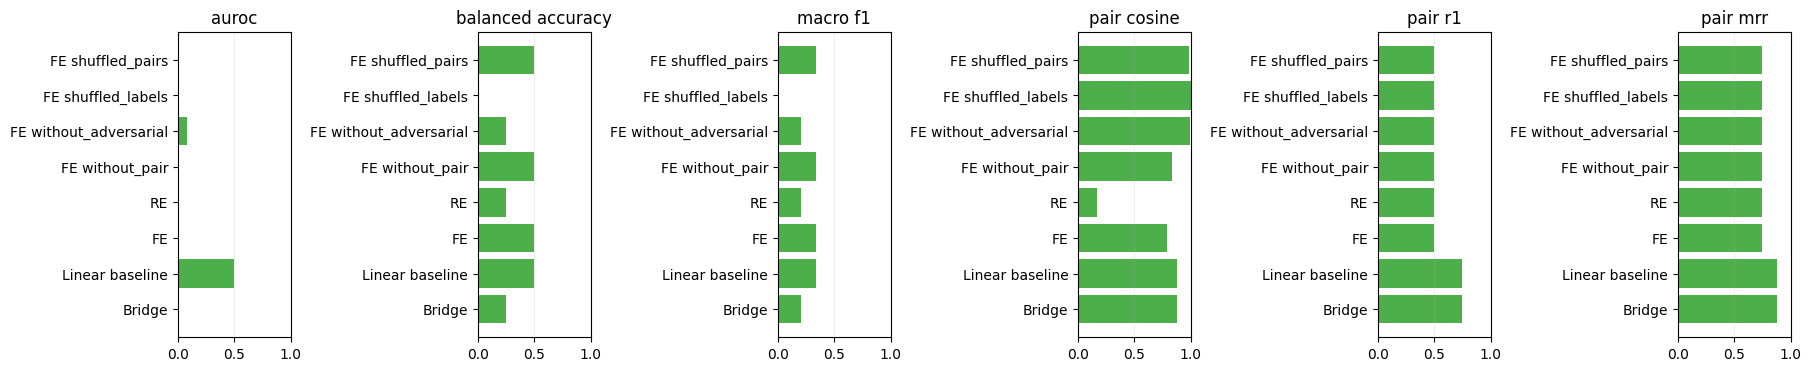

In [4]:
summary = read_csv(RESULTS/'task4_disentanglement/main_summary.csv')
if summary.empty:
    display(Markdown('*Disentanglement results are not available yet.*'))
else:
    display(summary.style.format(precision=3, na_rep='—'))
    metrics = [c for c in ['auroc','balanced_accuracy','macro_f1','pair_cosine','pair_r1','pair_mrr'] if c in summary]
    fig, axes = plt.subplots(1, len(metrics), figsize=(3*len(metrics), 3.6), layout='constrained')
    for ax, column in zip(np.atleast_1d(axes), metrics):
        ax.barh(summary.representation, summary[column], color='#4daf4a')
        ax.set(title=column.replace('_',' '), xlim=(0,1)); ax.grid(axis='x', alpha=.2)
    plt.show()

FE is successful only if held-out library prediction falls while cross-library biological identity improves. RE should retain library-associated information. Linear removal, loss ablations, and shuffled controls test whether the neural decomposition adds value.

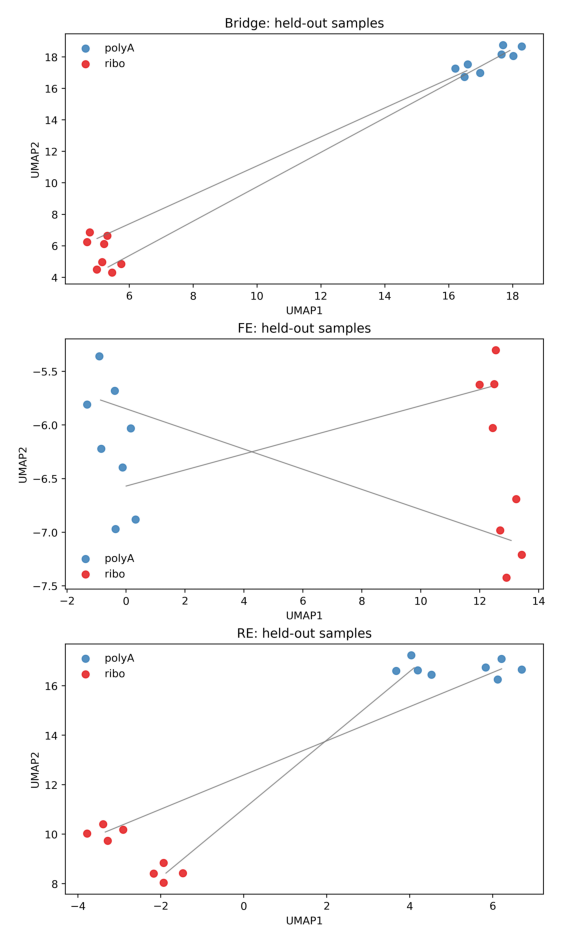

In [5]:
umap_png = RESULTS/'task4_disentanglement/heldout_representation_umaps.png'
if umap_png.exists():
    image = plt.imread(umap_png)
    plt.figure(figsize=(8,12)); plt.imshow(image); plt.axis('off'); plt.show()

## 4. Independent Task 3 challenge

,representation,comparison,left,right,cosine,spearman,left_norm,right_norm
0,Bridge,RR1,RR1_OSD48_original_matched,RR1_OSD168_no-ERCC,-0.804,-0.170,0.932,0.485
1,Bridge,RR1 ERCC,RR1_OSD48_original_matched,RR1_OSD168_all_ERCC,-0.808,-0.163,0.932,0.507
2,Bridge,RR3-39,C01_OSD137_original_matched,C01_OSD168_all_ERCC,0.790,0.509,0.235,0.191
3,Bridge,RR3-40,C02_OSD137_original_matched,C02_OSD168_all_ERCC,0.917,0.878,0.149,0.179
4,Bridge,ERCC/no-ERCC,RR1_OSD168_no-ERCC,RR1_OSD168_all_ERCC,0.998,0.993,0.485,0.507
5,Linear baseline,RR1,RR1_OSD48_original_matched,RR1_OSD168_no-ERCC,-0.709,-0.591,0.607,0.404
6,Linear baseline,RR1 ERCC,RR1_OSD48_original_matched,RR1_OSD168_all_ERCC,-0.708,-0.586,0.607,0.419
7,Linear baseline,RR3-39,C01_OSD137_original_matched,C01_OSD168_all_ERCC,0.724,0.637,0.193,0.170
8,Linear baseline,RR3-40,C02_OSD137_original_matched,C02_OSD168_all_ERCC,0.881,0.866,0.124,0.136
9,Linear baseline,ERCC/no-ERCC,RR1_OSD168_no-ERCC,RR1_OSD168_all_ERCC,0.997,0.996,0.404,0.419


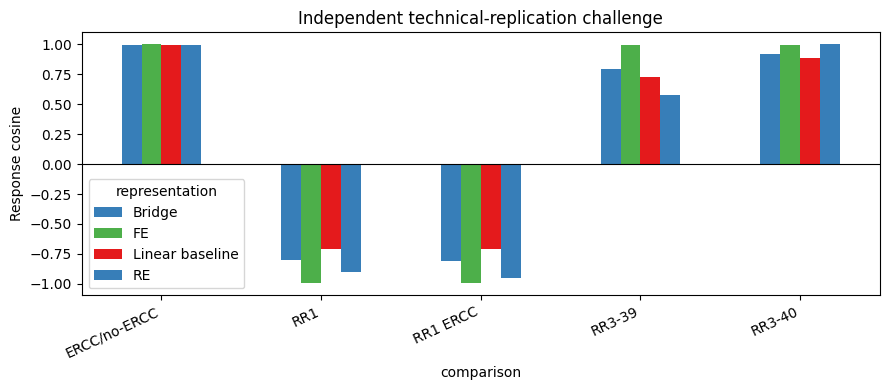

In [6]:
task3 = read_csv(RESULTS/'task4g_task3_challenge/task3_challenge_metrics.csv')
if task3.empty:
    display(Markdown('*Independent Task 3 application is not available yet.*'))
else:
    display(task3.style.format(precision=3))
    pivot = task3.pivot(index='comparison', columns='representation', values='cosine')
    ax = pivot.plot.bar(figsize=(9,4), color=['#377eb8','#4daf4a','#e41a1c'])
    ax.axhline(0,color='black',lw=.8); ax.set(ylabel='Response cosine', title='Independent technical-replication challenge')
    plt.xticks(rotation=25,ha='right'); plt.tight_layout(); plt.show()

Task 3 is an external challenge, not a tuning set. RR1 improvement matters only if RR3 and ERCC/no-ERCC relationships remain robust; changing the RR1 sign alone is not success.

## 5. Does RR1 align with a controlled PolyA→Ribo subspace?

This diagnostic uses only the **original frozen BridgeRNA embeddings**. The technical direction and SVD basis are learned from 40 verified same-RNA T-cell pairs; OSDR is used only afterward as an external diagnostic. Difference vectors are consistently defined as `Ribo − PolyA` or `OSD-168 new/Ribo-like − OSD-48 old/PolyA-like`.

The removal basis is the uncentered SVD of donor-wise differences, which retains their shared mean displacement. Centered PCA variance is also saved. This is a mechanism check—not a recommended correction.

,metric,result
0,Median controlled PolyA/Ribo pair cosine,0.9976
1,Median cosine among d_i,0.9802
2,Mean LOO technical-direction cosine,0.9860
3,LOO mismatched-null empirical p,0.0010
4,Uncentered PC1 variance explained,0.9747
5,Uncentered PC1-5 cumulative variance,0.9952
6,Independent blood alignment,-0.6572
7,Independent colon alignment,-0.7612
8,RR1 sample displacement median cosine with d_library,0.7885
9,RR1 sample displacement median variance captured PC1,0.6410


,metric,n,mean,median,sd,q25,q75,iqr
0,difference_norm,40,0.9644,0.9200,0.1698,0.8386,1.0597,0.2211
1,paired_embedding_cosine,40,0.9975,0.9976,0.0007,0.9971,0.9980,0.0009
2,pairwise_difference_cosine,780,0.9732,0.9802,0.0224,0.9675,0.9876,0.0200
3,loo_direction_cosine,40,0.9860,0.9895,0.0130,0.9860,0.9935,0.0075
4,loo_ribo_minus_polyA_projection,40,0.9512,0.9151,0.1678,0.8285,1.0516,0.2231


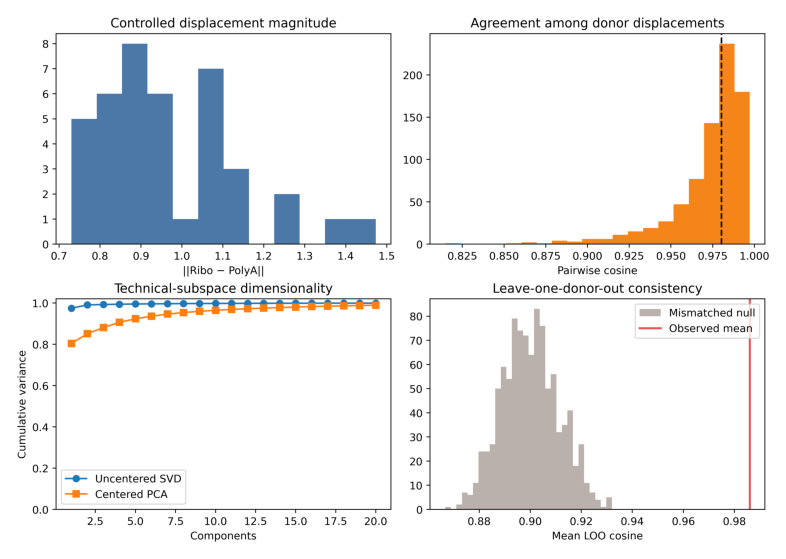

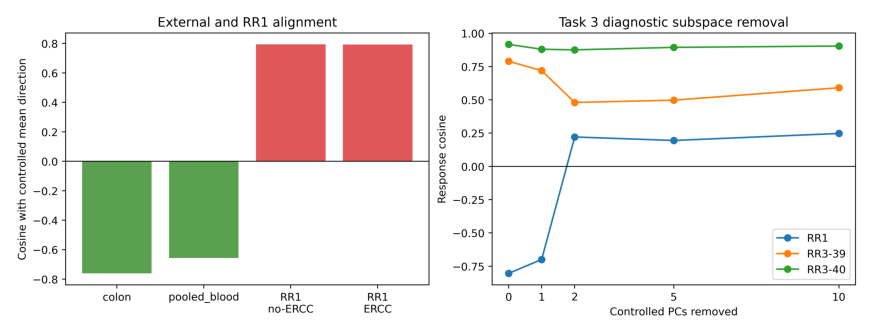

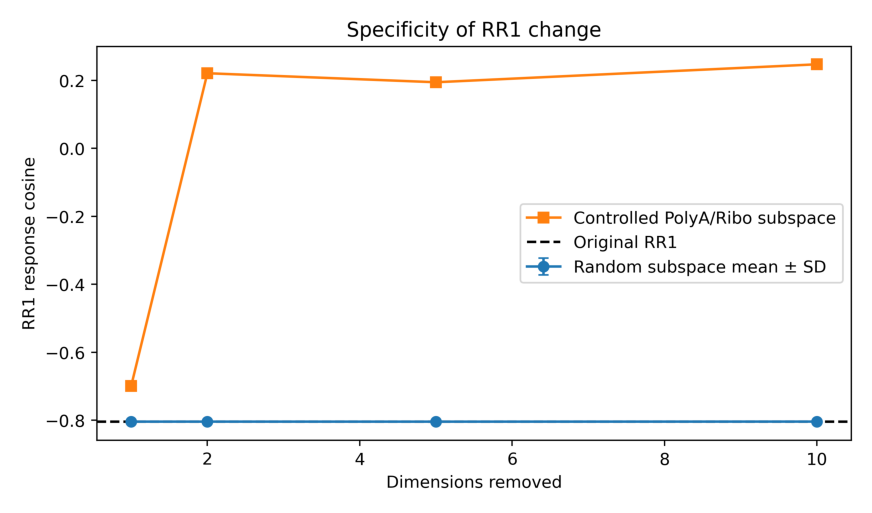

In [7]:
follow = RESULTS/'task4_followup_controlled_subspace'
diagnostic = read_csv(follow/'concise_summary.csv')
display(diagnostic.style.format({'result':'{:.4f}'}))
dist = read_csv(follow/'controlled_distribution_summary.csv')
display(dist.style.format(precision=4))
for name in ['controlled_library_geometry.png','external_rr1_alignment_and_removal.png','random_subspace_control.png']:
    path = follow/name
    if path.exists():
        img = plt.imread(path); plt.figure(figsize=(11,7)); plt.imshow(img); plt.axis('off'); plt.show()

### External orientation, correction specificity, and biological damage

An RR1 sign change is not sufficient evidence. We compare learned removal with 500 deterministic random subspaces per dimension and quantify how much original geometry, neighborhood structure, controlled pair retrieval, and RR3 technical preservation remain.

In [8]:
display(read_csv(follow/'independent_source_alignment.csv').style.format(precision=4))
display(read_csv(follow/'task3_response_after_subspace_removal.csv').style.format(precision=4))
display(read_csv(follow/'controlled_geometry_damage.csv').style.format(precision=4))
display(read_csv(follow/'random_subspace_rr1_summary.csv').style.format(precision=4))

,source,difference_norm,cosine_with_tcell_mean,fraction_magnitude_squared_in_pc1_1,fraction_magnitude_squared_in_pc1_2,fraction_magnitude_squared_in_pc1_5,fraction_magnitude_squared_in_pc1_10
0,colon,4.2291,-0.7612,0.5993,0.9689,0.9714,0.9796
1,pooled_blood,6.4471,-0.6572,0.4484,0.7842,0.8533,0.9172


,comparison,removed_components,cosine,spearman,norm_a,norm_b
0,RR1,0,-0.8041,-0.1702,0.9317,0.4853
1,RR1_ERCC,0,-0.8084,-0.1626,0.9317,0.5069
2,RR3-39,0,0.7900,0.5087,0.2347,0.1913
3,RR3-40,0,0.9166,0.8783,0.1486,0.1790
4,ERCC/no-ERCC,0,0.9981,0.9928,0.4853,0.5069
5,RR1,1,-0.6994,-0.5881,0.5935,0.3997
6,RR1_ERCC,1,-0.6985,-0.5822,0.5935,0.4139
7,RR3-39,1,0.7194,0.6354,0.1907,0.1688
8,RR3-40,1,0.8801,0.8657,0.1235,0.1347
9,ERCC/no-ERCC,1,0.9972,0.9961,0.3997,0.4139


,removed_components,mean_original_corrected_cosine,median_original_corrected_cosine,mean_top10_neighbor_overlap,variance_removed_fraction,median_pair_cosine,pair_r1,pair_r5,pair_r10,pair_mrr,median_rank
0,1,0.7743,0.7700,0.4700,0.4021,0.9999,0.8500,0.9250,0.9500,0.8878,1.0000
1,2,0.6724,0.6700,0.3212,0.5493,0.9999,1.0000,1.0000,1.0000,1.0000,1.0000
2,5,0.6604,0.6589,0.3137,0.5653,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,10,0.6309,0.6311,0.3137,0.6033,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,removed_components,mean,median,std,min,max,learned_rr1_cosine,fraction_random_at_least_as_improved
0,1,-0.8041,-0.8041,0.0007,-0.8082,-0.8011,-0.6994,0.0000
1,2,-0.8041,-0.8042,0.0009,-0.8074,-0.7995,0.2210,0.0000
2,5,-0.8042,-0.8042,0.0016,-0.8086,-0.7984,0.1945,0.0000
3,10,-0.8040,-0.8040,0.0022,-0.8106,-0.7954,0.2473,0.0000


The controlled T-cell effect is strongly reproducible *within that study*, and individual RR1 old→new displacements substantially project into the T-cell basis. However, held-out pooled blood and colon point in the opposite orientation. Five-component removal changes RR1 strongly and much more than random removal, but also removes a large fraction of embedding energy, disrupts neighborhoods, and weakens RR3-39. Therefore this supports **partial, context-dependent overlap**, not a universal PolyA/Ribo direction or a validated correction. The next correction effort should model the broader protocol transition and acquire additional independent same-RNA studies rather than treating library selection alone as established causality.

## 6. Final benchmark summary

In [9]:
if not summary.empty:
    final = summary.rename(columns={'representation':'Representation','auroc':'PolyA/Ribo AUROC','pair_cosine':'Pair cosine','pair_r1':'Pair R@1'})
    if not task3.empty:
        challenge = task3.pivot(index='representation',columns='comparison',values='cosine').reset_index().rename(columns={'representation':'Representation'})
        final = final.merge(challenge, on='Representation', how='left')
    final = final.rename(columns={'biology_metric_value':'Biology metric (source-ID MRR)'})
    keep = [c for c in ['Representation','PolyA/Ribo AUROC','Pair cosine','Pair R@1','Biology metric (source-ID MRR)','macro_f1','RR1','RR3-39','RR3-40'] if c in final]
    display(final[keep].style.format(precision=3,na_rep='—'))

,Representation,PolyA/Ribo AUROC,Pair cosine,Pair R@1,Biology metric (source-ID MRR),macro_f1,RR1,RR3-39,RR3-40
0,Bridge,0.000,0.882,0.750,0.875,0.200,-0.804,0.790,0.917
1,Linear baseline,0.500,0.883,0.750,0.875,0.333,-0.709,0.724,0.881
2,FE,0.000,0.786,0.500,0.750,0.333,-0.994,0.998,0.995
3,RE,0.000,0.165,0.500,0.750,0.200,-0.902,0.580,0.999
4,FE without_pair,0.000,0.838,0.500,0.750,0.333,—,—,—
5,FE without_adversarial,0.078,0.996,0.500,0.750,0.200,—,—,—
6,FE shuffled_labels,0.000,1.000,0.500,0.750,0.000,—,—,—
7,FE shuffled_pairs,0.000,0.986,0.500,0.750,0.333,—,—,—


## 7. Conservative interpretation

The completed evidence should answer whether original Bridge encodes library information, whether displacement generalizes, whether FE reduces it without erasing biology, whether RE isolates it, whether the decomposition generalizes, and whether RR1 improves without damaging RR3.

Until several independent authoritative same-RNA studies are available, generalization and causal attribution remain provisional. The current external test contains only two biological source RNAs, so effect sizes and failures matter more than nominal significance.

In [10]:
if not summary.empty and not task3.empty:
    s = summary.set_index('representation')
    t = task3.pivot(index='representation',columns='comparison',values='cosine')
    print(f"Held-out Bridge AUROC: {s.loc['Bridge','auroc']:.3f}; FE AUROC: {s.loc['FE','auroc']:.3f}; RE AUROC: {s.loc['RE','auroc']:.3f}")
    print(f"Pair cosine Bridge→FE: {s.loc['Bridge','pair_cosine']:.3f} → {s.loc['FE','pair_cosine']:.3f}")
    print(f"Pair R@1 Bridge→FE: {s.loc['Bridge','pair_r1']:.3f} → {s.loc['FE','pair_r1']:.3f}")
    print(f"RR1 cosine Bridge→FE: {t.loc['Bridge','RR1']:.3f} → {t.loc['FE','RR1']:.3f}")
    print('Conclusion: this exploratory FE/RE fit does not meet the predefined success criteria. It neither improves held-out pair correspondence nor remedies RR1. The result cannot specifically implicate PolyA/Ribo; the RR1 reversal remains attributable to a broader protocol transition.')

Held-out Bridge AUROC: 0.000; FE AUROC: 0.000; RE AUROC: 0.000
Pair cosine Bridge→FE: 0.882 → 0.786
Pair R@1 Bridge→FE: 0.750 → 0.500
RR1 cosine Bridge→FE: -0.804 → -0.994
Conclusion: this exploratory FE/RE fit does not meet the predefined success criteria. It neither improves held-out pair correspondence nor remedies RR1. The result cannot specifically implicate PolyA/Ribo; the RR1 reversal remains attributable to a broader protocol transition.
